In [31]:
!pip install spacy
!python -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 60.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [32]:
import os
import re
import pickle
import logging
from abc import ABC, abstractmethod
from functools import wraps
from dataclasses import dataclass
from typing import Any, Callable, Generator, Generic, List, Optional, TypeVar, Tuple

# Сторонние библиотеки
import pandas as pd
import spacy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
nlp = spacy.load("ru_core_news_sm")

from google.colab import drive
drive.mount('/content/drive')

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - [%(levelname)s] - %(message)s",
    force=True,  # <-- Этот параметр сбросит старые настройки Colab и включит INFO
)

T = TypeVar('T')
U = TypeVar('U')

# =====================================================================
# 1. МОНАДА RESULT И ДЕКОРАТОР @safe
# =====================================================================
@dataclass(frozen=True)
class Result(Generic[T]):
    """Чистая монада Result, самостоятельно управляющая потоком вычислений (Flow)"""

    is_success: bool
    value: Optional[T] = None
    error_message: Optional[str] = None

    @classmethod
    def success(cls, value: T) -> "Result[T]":
        return cls(is_success=True, value=value)

    @classmethod
    def failure(cls, error_message: str) -> "Result[T]":
        return cls(is_success=False, error_message=error_message)

    def then(
        self, func: Callable[[T], Any]
    ) -> "Result[Any]":  # <-- ИСТИННЫЙ МОНАДИЧЕСКИЙ BIND
        """Если в контейнере ошибка — лениво пробрасывает её дальше.

        Если успех — безопасно применяет функцию к значению и возвращает новый
        Result.
        """
        if not self.is_success:
            return self  # Ошибка транзитом летит в самый конец конвейера

        try:
            res = func(self.value)
            # Если функция внутри себя уже вернула Result, не запаковываем дважды
            if isinstance(res, Result):
                return res
            return Result.success(res)
        except Exception as e:
            logging.error(f"Критический сбой на этапе [{func.__name__}]: {e}")
            return Result.failure(str(e))



def safe(func: Callable[..., Any]) -> Callable[..., Result[Any]]:
    """Декоратор @safe, автоматически упаковывающий выходы и исключения в Result"""
    @wraps(func)
    def wrapper(*args: Any, **kwargs: Any) -> Result[Any]:
        try:
            res = func(*args, **kwargs)
            if isinstance(res, Result):
                return res
            return Result.success(res)
        except Exception as e:
            logging.error(f"Исключение перехвачено в @safe [{func.__name__}]: {str(e)}")
            return Result.failure(str(e))
    return wrapper

# =====================================================================
# 2. ИНТЕРФЕЙС DATA SCIENCE ШАГА (Fit / Transform Контракт)
# =====================================================================
class DSPipelineStep(ABC):
    """Абстрактный класс для шагов обработки потока данных (flow)"""

    def fit(self, data_flow: Generator[Any, None, None]) -> 'DSPipelineStep':
        """Обучение шага (если требуется). По умолчанию возвращает сам себя."""
        return self

    @abstractmethod
    def transform(self, data_flow: Generator[Any, None, None]) -> Generator[Any, None, None]:
        """Трансформация потока данных (фильтрация, очистка, лемматизация)"""
        pass

# =====================================================================
# 3. РЕАЛИЗАЦИЯ СТАДИЙ ПРЕДОБРАБОТКИ (Flow-трансформации)
# =====================================================================

class FlowRegexCleaner(BaseEstimator, TransformerMixin):
    """Шаг 1: Первичная очистка текста регулярными выражениями и разметка иронии"""
    def __init__(self):
        self.URL_PATTERN = re.compile(r'https?://\s*\S+|www\.\S+')
        self.USER_HASH_PATTERN = re.compile(r'[@#]\w+')
        self.CLEAN_TEXT_PATTERN = re.compile(r'[^а-яa-z\s]')
        self.MULTIPLE_SPACES_PATTERN = re.compile(r'\s+')

    def _clean_with_irony_markers(self, text: str) -> str:
        if not isinstance(text, str):
            return ""
        text = text.lower().replace('ё', 'е')
        # Заменяем кавычки вокруг слов на специальный токен иронии
        text = re.sub(r'["«]([^"»\s]+)["»]', r' irony_quotes \1 ', text)
        # Заменяем многоточия
        text = text.replace('...', ' token_ellipsis ')

        # Основная зачистка регулярными выражениями
        text = self.URL_PATTERN.sub('', text)
        text = self.USER_HASH_PATTERN.sub('', text)
        text = self.CLEAN_TEXT_PATTERN.sub(' ', text)
        return self.MULTIPLE_SPACES_PATTERN.sub(' ', text).strip()

    def fit(self, X, y=None):
        return self

    def transform(self, X: List[dict]) -> List[str]:
        # На входе — список сырых словарей из load_and_prepare_raw_data
        # На выходе — строго список очищенных СТРОК
        return [self._clean_with_irony_markers(item.get("ttext", "")) for item in X]


class FlowSpacyLemmatizer(BaseEstimator, TransformerMixin):
    """Шаг 2: Высокоскоростная параллельная лемматизация через spaCy pipeline"""
    def __init__(self, batch_size: int = 2048):
        self.batch_size = batch_size
        logging.info("Инициализация высокоскоростного spaCy (ru_core_news_sm)...")
        self.nlp = spacy.load("ru_core_news_sm")
        self.num_cpus = os.cpu_count() or 2
        logging.info(f"Доступно ядер CPU для распараллеливания: {self.num_cpus}")

    def fit(self, X, y=None):
        return self

    def transform(self, X: List[str]) -> List[str]:
            # На входе — список строк от регулярных выражений
            buffer: List[str] = []
            output: List[str] = []

            with self.nlp.select_pipes(enable=["tok2vec", "morphologer", "tagger", "lemmatizer"]):
                for text in X:
                    buffer.append(text)
                    if len(buffer) >= self.batch_size:
                        # Извлекаем леммы из пачки текстов
                        docs = self.nlp.pipe(buffer, n_process=-1, batch_size=self.batch_size)
                        for doc in docs:
                            words = [t.lemma_ for t in doc if len(t.lemma_.strip()) > 1 and not t.is_stop]
                            output.append(" ".join(words).strip())
                        buffer.clear()
                if buffer:
                    docs = self.nlp.pipe(buffer, n_process=-1, batch_size=self.batch_size)
                    for doc in docs:
                        words = [t.lemma_ for t in doc if len(t.lemma_.strip()) > 1 and not t.is_stop]
                        output.append(" ".join(words).strip())

            return output # На выходе — строго список лемматизированных СТРОК


    def _process_batch(self, batch: List[dict]) -> Generator[dict, None, None]:
        texts = [item["cleaned_text"] for item in batch]

        # n_process=-1 задействует все доступные ядра CPU в Google Colab
        docs = self.nlp.pipe(texts, n_process=-1, batch_size=self.batch_size)

        for item, doc in zip(batch, docs):
            # Лемматизируем, убираем стоп-слова и токены длиной менее 2 символов
            words = [
                token.lemma_ for token in doc
                if len(token.lemma_.strip()) > 1 and not token.is_stop
            ]
            final_text = " ".join(words).strip()

            # Пропускаем строки, если после лемматизации они стали пустыми
            if final_text != "":
                item["cleaned_text"] = final_text
                yield item

# =====================================================================
# 4. УПРАВЛЯЮЩИЙ DATA SCIENCE ПАЙПЛАЙН (Конвейер)
# =====================================================================
class DataSciencePipeline:
    """Управляющий класс, координирующий fit и transform над общим потоком (flow)"""
    def __init__(self):
        self.steps: List[DSPipelineStep] = []

    def add_step(self, step: DSPipelineStep) -> 'DataSciencePipeline':
        self.steps.append(step)
        return self

    @safe
    def fit(self, raw_data: List[dict]) -> 'DataSciencePipeline':
        """Метод последовательного обучения компонентов (если бы у нас был TF-IDF/Токенизатор)"""
        flow = (item for item in raw_data)
        for step in self.steps:
            step.fit(flow)
            flow = step.transform(flow)
        return self

    @safe
    def transform(self, raw_data: List[dict]) -> List[dict]:
        """Прогоняет выборку через весь трансформирующий flow конвейера"""
        flow = (item for item in raw_data)
        for step in self.steps:
            flow = step.transform(flow)
        # На выходе материализуем ленивый поток обратно в список словарей
        return list(flow)

# =====================================================================
# 5. БЕЗОПАСНАЯ И Lazy-ОПТИМИЗИРОВАННАЯ ЗАГРУЗКА ДАННЫХ
# =====================================================================
@safe
def load_and_prepare_raw_data(pos_path: str, neg_path: str) -> List[dict]:
    """Безопасно читает CSV, маппит таргеты, выравнивает классы и преобразует в список словарей"""
    logging.info("Чтение сырых файлов с Google Drive...")

    pos_df = pd.read_csv(pos_path, sep=',', quotechar='"', on_bad_lines='skip')[['ttext', 'ttype']].copy()
    neg_df = pd.read_csv(neg_path, sep=',', quotechar='"', on_bad_lines='skip')[['ttext', 'ttype']].copy()
    df = pd.concat([pos_df, neg_df], ignore_index=True)

    # Стандартизация таргетов и заполнение пропусков
    df['ttype'] = df['ttype'].fillna(0).astype(int).map({1: 1, -1: 0, 0: 0})
    df['ttext'] = df['ttext'].fillna("")

    # === ВСТАВКА ДЛЯ ВЫРАВНИВАНИЯ ДАННЫХ ===
    logging.info(f"Распределение классов до выравнивания:\n{df['ttype'].value_counts()}")
    min_size = df['ttype'].value_counts().min()

    df_balanced = pd.concat([
        df[df['ttype'] == 1].sample(n=min_size, random_state=42),
        df[df['ttype'] == 0].sample(n=min_size, random_state=42)
    ], ignore_index=True)
    logging.info(f"Классы выровнены! Размер: {len(df_balanced)} строк ({min_size} на класс).")
    # ======================================

    # Конвертируем уже сбалансированный DataFrame в поток словарей
    return df_balanced.to_dict(orient='records')

@dataclass(frozen=True)
class ExperimentContext:
    """Контекст эксперимента, передаваемый по цепочке FlowManager"""
    pipeline: Optional[Pipeline]  # <-- используем стандартный Pipeline из sklearn
    train_data: List[dict]
    test_data: List[dict]
    train_transformed: Optional[dict] = None
    test_transformed: Optional[dict] = None
    is_cached: bool = False
    nn_step: Optional[Any] = None


2026-06-07 23:00:59,100 - [INFO] - Loading dictionaries from /usr/local/lib/python3.12/dist-packages/pymorphy3_dicts_ru/data
2026-06-07 23:00:59,211 - [INFO] - format: 2.4, revision: 417150, updated: 2022-01-08T22:09:24.565962


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import logging
import torch.nn as nn


class TextMLP(nn.Module):

    def __init__(self, input_dim: Any):
        super(TextMLP, self).__init__()
        # мы берем строго индекс 1 (количество фичей = 40000).
        if isinstance(input_dim, (tuple, list, torch.Size)):
            features_dim = input_dim[1]
        else:
            features_dim = input_dim

        print(
            f"[NETWORK INFO] Инициализация nn.Linear. Входной слой: {features_dim} признаков."
        )

        self.network = nn.Sequential(
            nn.Linear(features_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x)


In [34]:
class DSTfidfVectorizerStep(BaseEstimator, TransformerMixin):
    """Шаг 3: Обучение TF-IDF на Train (fit) и векторизация текстов (transform)"""
    def __init__(self, max_features: int = 40000, min_df: int = 2, ngram_range: tuple = (1, 3)):
        self.vectorizer = TfidfVectorizer(max_features=max_features, min_df=min_df, ngram_range=ngram_range)

    def fit(self, X: List[str], y=None):
        # Получает на вход чистый список строк от лемматизатора
        if X:
            self.vectorizer.fit(X)
        return self

    def transform(self, X: List[str]) -> Any:
        # Возвращает чистую разреженную матрицу Scipy
        return self.vectorizer.transform(X)


class DSNeuralNetworkStep(BaseEstimator, TransformerMixin):
    """Шаг 4: Создание DataLoader, обучение PyTorch MLP и валидация"""
    def __init__(self, epochs: int = 6, batch_size: int = 512, lr: float = 0.0002, patience: int = 1):
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None

    def _make_loader(self, X_sparse, y_labels, shuffle=True):
        indices = torch.arange(X_sparse.shape[0])
        labels = torch.tensor(y_labels, dtype=torch.float32)
        dataset = TensorDataset(indices, labels)
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=shuffle)

    def fit_and_evaluate(self, train_data: dict, test_data: dict, y=None):
        logging.info(f"Обучение нейросети запущено на устройстве: {self.device}")
        X_train, y_train = train_data["X"], train_data["y"]
        X_test, y_test = test_data["X"], test_data["y"]

        train_loader = self._make_loader(X_train, y_train, shuffle=True)
        test_loader = self._make_loader(X_test, y_test, shuffle=False)
        input_size = X_train.shape[1]
        #self.model = TextMLP(input_size).to(self.device)
        self.model = TextMLP(X_train.shape).to(self.device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=1e-4)

        best_val_loss = float('inf')
        patience_counter = 0
        for epoch in range(self.epochs):
            # --- TRAIN ---
            self.model.train()
            running_train_loss = 0.0
            for idx_batch, labels_batch in train_loader:
                inputs_batch = torch.tensor(X_train[idx_batch.numpy()].toarray(), dtype=torch.float32).to(self.device)
                #labels_batch = labels_batch.to(self.device).unsqueeze(1)
                labels_batch = labels_batch.to(self.device).view(-1, 1)

                optimizer.zero_grad()
                outputs = self.model(inputs_batch)
                loss = criterion(outputs, labels_batch)
                loss.backward()
                optimizer.step()

                running_train_loss += loss.item() * inputs_batch.size(0)
            epoch_train_loss = running_train_loss / X_train.shape[0]

            # --- VALIDATION ---
            self.model.eval()
            running_val_loss = 0.0
            val_preds, val_true = [], []

            with torch.no_grad():
                for idx_batch, labels_batch in test_loader:
                    inputs_batch = torch.tensor(X_test[idx_batch.numpy()].toarray(), dtype=torch.float32).to(self.device)
                    #labels_true = labels_batch.to(self.device).unsqueeze(1)
                    labels_true = labels_batch.to(self.device).view(-1, 1)

                    outputs = self.model(inputs_batch)
                    loss = criterion(outputs, labels_true)
                    running_val_loss += loss.item() * inputs_batch.size(0)

                    preds = torch.sigmoid(outputs).cpu().numpy()
                    val_preds.extend((preds > 0.5).astype(int).flatten())
                    val_true.extend(labels_batch.numpy())

            epoch_val_loss = running_val_loss / X_test.shape[0]
            epoch_val_acc = accuracy_score(val_true, val_preds)

            logging.info(f"Эпоха {epoch+1}/{self.epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Accuracy: {epoch_val_acc:.4f}")

            # Early Stopping
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                patience_counter = 0
                torch.save(self.model.state_dict(), 'best_model.pth')
            else:
                patience_counter += 1
                if patience_counter > self.patience:
                    logging.info(f"[Early Stopping] Обучение остановлено на эпохе {epoch+1}.")
                    break
        return self

    def transform(self, data_flow: Generator[dict, None, None]) -> Generator[Any, None, None]:
        # Оставляем контракт интерфейса пустым, так как этот шаг — конечная точка обучения
        return data_flow


In [35]:
import gc
import torch

# 1. Удаляем из памяти старые ссылки на модель и оптимизатор, если они зависли
if "model" in globals():
    del model
if "optimizer" in globals():
    del optimizer
if "inputs_batch" in globals():
    del inputs_batch

# 2. Принудительно запускаем сборщик мусора Python
gc.collect()

# 3. Очищаем внутренний кэш аллокатора PyTorch для видеокарты (VRAM)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(
        f"✓ Память GPU очищена. Свободно: {torch.cuda.mem_get_info()[0] / 1024**2:.2f} MB из {torch.cuda.mem_get_info()[1] / 1024**2:.2f} MB"
    )
else:
    print("CUDA недоступна, чистить нечего.")

CUDA недоступна, чистить нечего.


2026-06-07 23:01:03,767 - [INFO] - Чтение сырых файлов с Google Drive...
2026-06-07 23:01:07,035 - [INFO] - Распределение классов до выравнивания:
ttype
1    114911
0    111923
Name: count, dtype: int64
2026-06-07 23:01:07,194 - [INFO] - Классы выровнены! Размер: 223846 строк (111923 на класс).
2026-06-07 23:01:08,620 - [INFO] - --- [FLOW] Обнаружен готовый кэш матриц на Google Диске. Загрузка... ---
2026-06-07 23:01:22,338 - [INFO] - Loading dictionaries from /usr/local/lib/python3.12/dist-packages/pymorphy3_dicts_ru/data
2026-06-07 23:01:22,400 - [INFO] - format: 2.4, revision: 417150, updated: 2022-01-08T22:09:24.565962
2026-06-07 23:01:22,910 - [INFO] - Кэш успешно загружен. Тяжелые стадии предобработки будут пропущены.
2026-06-07 23:01:22,913 - [INFO] - --- [FLOW] Запуск финальной стадии: Обучение PyTorch MLP модели ---
2026-06-07 23:01:22,920 - [INFO] - Обучение нейросети запущено на устройстве: cpu


[NETWORK INFO] Инициализация nn.Linear. Входной слой: 40000 признаков.


2026-06-07 23:03:57,130 - [INFO] - Эпоха 1/6 | Train Loss: 0.6555 | Val Loss: 0.5773 | Val Accuracy: 0.7037
2026-06-07 23:06:19,408 - [INFO] - Эпоха 2/6 | Train Loss: 0.5388 | Val Loss: 0.5467 | Val Accuracy: 0.7167
2026-06-07 23:08:40,593 - [INFO] - Эпоха 3/6 | Train Loss: 0.4993 | Val Loss: 0.5489 | Val Accuracy: 0.7158
2026-06-07 23:11:06,788 - [INFO] - Эпоха 4/6 | Train Loss: 0.4763 | Val Loss: 0.5538 | Val Accuracy: 0.7151
2026-06-07 23:11:06,788 - [INFO] - [Early Stopping] Обучение остановлено на эпохе 4.
2026-06-07 23:11:06,799 - [INFO] - --- [FLOW] Запуск финального тестирования модели ---


[NETWORK INFO] Инициализация nn.Linear. Входной слой: 40000 признаков.


2026-06-07 23:11:24,701 - [INFO] - --- [FLOW] Запуск стадии детального расчёта метрик на CPU ---



=== Исправленные результаты на тестовой выборке ===
              precision    recall  f1-score   support

  Негативный       0.72      0.72      0.72     22458
  Позитивный       0.72      0.72      0.72     22312

    accuracy                           0.72     44770
   macro avg       0.72      0.72      0.72     44770
weighted avg       0.72      0.72      0.72     44770


=== КЛЮЧЕВЫЕ МЕТРИКИ КЛАССИФИКАЦИИ ===
Accuracy: 0.7151 | Precision: 0.7154 | Recall: 0.7113 | F1-score: 0.7133



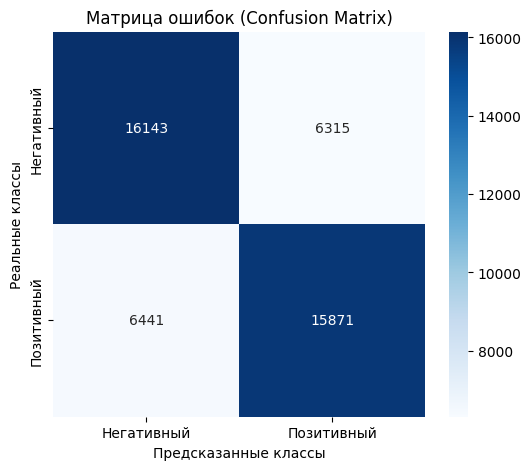

2026-06-07 23:11:43,230 - [INFO] - --- [FLOW] Побатчевый точный расчет градиентной важности признаков ---


=== АНАЛИЗ НАПРАВЛЕНИЯ ОШИБОК ===
False Positives: 6315 (Модель пропустила негатив)
False Negatives: 6441 (Модель не заметила позитив)

[NETWORK INFO] Инициализация nn.Linear. Входной слой: 40000 признаков.


2026-06-07 23:12:15,924 - [INFO] - --- [FLOW] Запуск стадии ручного инференса на сложных предложениях ---



=== ТОП-20 ПОЗИТИВНЫХ СЛОВ ===
dd                        | Вес: 7.6394
ddd                       | Вес: 6.3943
dddd                      | Вес: 4.8937
xd                        | Вес: 4.6194
ddddd                     | Вес: 3.0451
приятно                   | Вес: 2.8256
нужный ёлка               | Вес: 2.7367
ахахахах                  | Вес: 2.6766
нужный ёлка новый         | Вес: 2.6701
смех                      | Вес: 2.6573
хах                       | Вес: 2.6473
полезно                   | Вес: 2.5311
rt делишки                | Вес: 2.4860
делишки сделать           | Вес: 2.4817
rt делишки сделать        | Вес: 2.4770
любить проводить          | Вес: 2.4431
ахах                      | Вес: 2.4315
любить проводить вечер    | Вес: 2.4301
декабрь день              | Вес: 2.3982
царевич серый             | Вес: 2.3765

=== ТОП-20 НЕГАТИВНЫХ СЛОВ ===
обидно                    | Вес: -3.9953
грустно                   | Вес: -3.7888
печально                  | Вес: -3.6416
печаль       

2026-06-07 23:12:17,234 - [INFO] - ✓ Пайплайн завершен успешно: Инженерный монадический Data Science пайплайн полностью выполнен!


Фраза:      "Фильм был вообще не отличный и совсем не интересный."
Результат:  Позитивный (Уверенность: 93.33%)
--------------------------------------------------


In [36]:
# =====================================================================
# МЕНЕДЖЕР ПОТОКА (Flow Manager)
# =====================================================================
class FlowManager:
    """Управляющий класс, который автоматически протягивает Context по цепочке функций.
    """

    def __init__(self, initial_result: Result[Any]):
        # Начинаем движение с упакованного стартового результата (например, загруженных данных)
        self.current_result = initial_result

    def then(
            self, flow_function: Callable[[Any], Result[Any]]
        ) -> "FlowManager":
            """Автоматически связывает текущее состояние с новой функцией через flat_map"""
            # Подстраховка: если внутри value лежит еще один Result, распаковываем его перед flat_map
            if (
                self.current_result.is_success
                and hasattr(self.current_result.value, "value")
                and isinstance(self.current_result.value, Result)
            ):
                self.current_result = self.current_result.value

            self.current_result = self.current_result.flat_map(flow_function)
            return self

    def execute(self) -> Result[Any]:
        """Возвращает финальный контейнер Result после прохождения всего потока"""
        return self.current_result


# =====================================================================
# ИЗОЛИРОВАННЫЕ СТАДИИ ЭКСПЕРИМЕНТА (Все защищены @safe)
# =====================================================================
@safe
def init_context(raw_data: List[dict]) -> ExperimentContext:
    """Шаг 1: Разделение данных и инициализация Pipeline с TF-IDF"""
    output_dir = '/content/drive/MyDrive/sentiment/matrix_data'

    # Декларативно прописываем точные пути к файлам кэша
    X_train_path = os.path.join(output_dir, "X_train.npz")
    X_test_path = os.path.join(output_dir, "X_test.npz")
    y_train_path = os.path.join(output_dir, "y_train.npy")
    y_test_path = os.path.join(output_dir, "y_test.npy")
    pipeline_path = os.path.join(output_dir, "pipeline.pkl")

    cache_files = [
        X_train_path,
        X_test_path,
        y_train_path,
        y_test_path,
        pipeline_path,
    ]

    # Если ВСЕ файлы существуют, загружаем их напрямую
    if all(os.path.exists(f) for f in cache_files):
        logging.info("--- [FLOW] Обнаружен готовый кэш матриц на Google Диске. Загрузка... ---")
        from scipy.sparse import load_npz

        train_transformed = {"X": load_npz(cache_files[0]), "y": np.load(cache_files[2])}
        test_transformed = {"X": load_npz(cache_files[1]), "y": np.load(cache_files[3])}

        with open(cache_files[4], 'rb') as f:
            cached_pipeline = pickle.load(f)

        logging.info("Кэш успешно загружен. Тяжелые стадии предобработки будут пропущены.")
        return ExperimentContext(
            pipeline=cached_pipeline, train_data=[], test_data=[],
            train_transformed=train_transformed, test_transformed=test_transformed,
            is_cached=True
        )

    logging.info("Кэш не найден. Запуск полной сборки Sklearn Pipeline и разделения данных...")
    logging.info(f"Загружено {len(raw_data)} строк. Разделение данных и сборка Pipeline...")
    train_data, test_data = train_test_split(raw_data, test_size=0.2, random_state=42)

    # Добавляем в пайплайн наш новый шаг векторизации TF-IDF
    #pipeline = (DataSciencePipeline()
    #            .add_step(FlowRegexCleaner())
    #            .add_step(FlowSpacyLemmatizer(batch_size=2048))
    #            .add_step(DSTfidfVectorizerStep(max_features=40000)))
    pipeline = Pipeline([
        ('cleaner', FlowRegexCleaner()),
        ('lemmatizer', FlowSpacyLemmatizer(batch_size=2048)),
        ('tfidf', DSTfidfVectorizerStep(max_features=40000)),
        ("nn_model", DSNeuralNetworkStep())
    ])
    return ExperimentContext(pipeline=pipeline, train_data=train_data, test_data=test_data)

@safe
def flow_transform_train(ctx: ExperimentContext) -> ExperimentContext:
    if ctx.is_cached: return ctx
    logging.info("--- [FLOW] Векторизация выборки TRAIN через Pipeline ---")

    # 1. Извлекаем сырые тексты и таргеты отдельно по правилам Data Science
    X_raw = ctx.train_data
    y_labels = np.array([item["ttype"] for item in ctx.train_data], dtype=np.float32)

    # 2. Прогоняем через пайплайн. Теперь здесь ГАРАНТИРОВАННО будет разреженная матрица Scipy X
    X_sparse = ctx.pipeline.transform(X_raw)
    if hasattr(X_sparse, 'value'): X_sparse = X_sparse.value

    # 3. Собираем правильный словарь матриц
    train_matrix_dict = {"X": X_sparse, "y": y_labels}

    return ExperimentContext(
        pipeline=ctx.pipeline, train_data=ctx.train_data, test_data=ctx.test_data,
        train_transformed=train_matrix_dict, is_cached=ctx.is_cached, nn_step=ctx.nn_step
    )

@safe
def flow_transform_test(ctx: ExperimentContext) -> ExperimentContext:
    if ctx.is_cached: return ctx
    logging.info("--- [FLOW] Векторизация выборки TEST через Pipeline ---")

    X_raw = ctx.test_data
    y_labels = np.array([item["ttype"] for item in ctx.test_data], dtype=np.float32)

    X_sparse = ctx.pipeline.transform(X_raw)
    if hasattr(X_sparse, 'value'): X_sparse = X_sparse.value

    test_matrix_dict = {"X": X_sparse, "y": y_labels}

    return ExperimentContext(
        pipeline=ctx.pipeline, train_data=ctx.train_data, test_data=ctx.test_data,
        train_transformed=ctx.train_transformed, test_transformed=test_matrix_dict,
        is_cached=ctx.is_cached,
        nn_step=ctx.nn_step
    )

@safe
def flow_fit(ctx: ExperimentContext) -> ExperimentContext:
    if ctx.is_cached: return ctx
    logging.info("--- [FLOW] Запуск стадии FIT (Обучение всего Sklearn Pipeline) ---")

    ctx.pipeline.fit(ctx.train_data)

    # Передаем этот же пайплайн дальше по цепочке
    return ExperimentContext(
        pipeline=ctx.pipeline,
        train_data=ctx.train_data,
        test_data=ctx.test_data,
        is_cached=ctx.is_cached,
        nn_step=ctx.nn_step
    )

@safe
def flow_save_results(ctx: ExperimentContext) -> ExperimentContext:
    if ctx.is_cached: return ctx
    output_dir = '/content/drive/MyDrive/sentiment/matrix_data'
    os.makedirs(output_dir, exist_ok=True)
    logging.info(f"--- [FLOW] Экспорт векторизованных матриц и Pipeline в {output_dir} ---")

    # Сохраняем матрицы и метки
    from scipy.sparse import save_npz
    save_npz(os.path.join(output_dir, 'X_train.npz'), ctx.train_transformed["X"])
    save_npz(os.path.join(output_dir, 'X_test.npz'), ctx.test_transformed["X"])
    np.save(os.path.join(output_dir, 'y_train.npy'), ctx.train_transformed["y"])
    np.save(os.path.join(output_dir, 'y_test.npy'), ctx.train_transformed["y"])

    # Сериализуем и сохраняем сам объект обученного Sklearn Pipeline
    with open(os.path.join(output_dir, 'pipeline.pkl'), 'wb') as f:
        pickle.dump(ctx.pipeline, f)

    logging.info("Все артефакты успешно экспортированы.")
    return ctx

@safe
def flow_train_neural_network(ctx: ExperimentContext) -> ExperimentContext:
    """Шаг 6: Финальный этап — обучение нейросети на векторизованных данных"""
    logging.info("--- [FLOW] Запуск финальной стадии: Обучение PyTorch MLP модели ---")

    # Инициализируем шаг нейросети
    nn_step = DSNeuralNetworkStep(epochs=6, batch_size=512, patience=1)

    # Обучаем модель, передавая ей векторизованные Train и Test данные из контекста
    nn_step.fit_and_evaluate(train_data=ctx.train_transformed, test_data=ctx.test_transformed)

    # Возвращаем контекст целиком, чтобы передать матрицы на следующие шаги оценки
    return ExperimentContext(
        pipeline=ctx.pipeline, train_data=ctx.train_data, test_data=ctx.test_data,
        train_transformed=ctx.train_transformed, test_transformed=ctx.test_transformed,
        is_cached=ctx.is_cached, nn_step=nn_step
    )

@safe
def flow_final_evaluation(ctx: ExperimentContext) -> str:
    """Шаг 7: Загрузка лучших весов и финальный замер метрик качества (Classification Report)"""
    logging.info("--- [FLOW] Запуск финального тестирования модели ---")

    # 1. Извлекаем данные из контекста
    X_test = ctx.test_transformed["X"]
    y_test = ctx.test_transformed["y"]

    # 2. Инициализируем модель и загружаем лучшие веса
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = TextMLP(X_test.shape[1]).to(device)
    model.load_state_dict(torch.load('best_model.pth', map_location=device))
    model.eval()

    # 3. Создаем тестовый лоадер (используем batch_size=512 из прошлого шага)
    indices = torch.arange(X_test.shape[0])
    dataset = TensorDataset(indices, torch.tensor(y_test))
    test_loader = DataLoader(dataset, batch_size=512, shuffle=False)

    # 4. Финальный замер предсказаний
    final_preds = []
    with torch.no_grad():
        for idx_batch, _ in test_loader:
            inputs_batch = torch.tensor(X_test[idx_batch.numpy()].toarray(), dtype=torch.float32).to(device)
            outputs = model(inputs_batch)
            preds = torch.sigmoid(outputs).cpu().numpy()
            final_preds.extend((preds > 0.5).astype(int).flatten())

    # 5. Печать и возврат отчета
    print("\n=== Исправленные результаты на тестовой выборке ===")
    report_str = classification_report(y_test, final_preds, target_names=['Негативный', 'Позитивный'])
    print(report_str)

    return ctx

@safe
def flow_interpret_model(ctx: ExperimentContext) -> ExperimentContext:
    logging.info("--- [FLOW] Побатчевый точный расчет градиентной важности признаков ---")

    X_train = ctx.train_transformed["X"]
    num_features = X_train.shape[1]

    vectorizer = ctx.pipeline.named_steps['tfidf'].vectorizer
    feature_names = vectorizer.get_feature_names_out()

    device = torch.device('cpu')
    model = TextMLP(num_features).to(device)
    if ctx.nn_step is not None and ctx.nn_step.model is not None:
        model = ctx.nn_step.model
    else:
        model.load_state_dict(torch.load('best_model.pth', map_location=device))
    model.eval()

    # Чтобы не перегружать ОЗУ, считаем градиенты пачками по 2000 признаков
    word_importance = np.zeros(num_features, dtype=np.float32)
    step_size = 2000

    for start_idx in range(0, num_features, step_size):
        end_idx = min(start_idx + step_size, num_features)
        current_chunk_size = end_idx - start_idx

        # Создаем фрагмент единичной матрицы для текущего батча фичей
        chunk_eye = np.zeros((current_chunk_size, num_features), dtype=np.float32)
        for i in range(current_chunk_size):
            chunk_eye[i, start_idx + i] = 1.0

        input_tensor = torch.tensor(chunk_eye, requires_grad=True, device=device)
        outputs = model(input_tensor)
        outputs.sum().backward()

        # Извлекаем чистые градиенты влияния для текущей пачки слов
        grads = input_tensor.grad.cpu().numpy()
        for i in range(current_chunk_size):
            word_importance[start_idx + i] = grads[i, start_idx + i]

    importance_df = pd.DataFrame({
        'word': feature_names,
        'weight': word_importance
    })

    top_positive = importance_df.sort_values(by='weight', ascending=False).head(20)
    top_negative = importance_df.sort_values(by='weight', ascending=True).head(20)

    print("\n=== ТОП-20 ПОЗИТИВНЫХ СЛОВ ===")
    for idx, row in top_positive.iterrows():
        print(f"{row['word']:<25} | Вес: {row['weight']:.4f}")

    print("\n=== ТОП-20 НЕГАТИВНЫХ СЛОВ ===")
    for idx, row in top_negative.iterrows():
        print(f"{row['word']:<25} | Вес: {row['weight']:.4f}")

    return ctx

@safe
def flow_detailed_metrics(ctx: ExperimentContext) -> ExperimentContext:
    logging.info(
        "--- [FLOW] Запуск стадии детального расчёта метрик на CPU ---"
    )

    X_test = ctx.test_transformed["X"]
    y_test = ctx.test_transformed["y"]

    # Вместо torch.load() достаем уже обученный шаг нейросети из Pipeline
    # и переводим модель в режим оценки
    #nn_step = ctx.pipeline.named_steps["nn_model"]
    nn_step = ctx.nn_step
    model = ctx.nn_step.model
    model.eval()

    device = torch.device("cpu")  # Явно фиксируем CPU инференс

    indices = torch.arange(X_test.shape[0])
    dataset = TensorDataset(indices, torch.tensor(y_test, dtype=torch.float32))
    test_loader = DataLoader(dataset, batch_size=2048, shuffle=False)

    all_preds = []
    all_true = []

    with torch.no_grad():
        for idx_batch, labels_batch in test_loader:
            # Побатчевая конвертация разреженной матрицы Scipy в плотный тензор
            inputs_batch = torch.tensor(
                X_test[idx_batch.numpy()].toarray(), dtype=torch.float32
            ).to(device)
            outputs = model(inputs_batch)
            preds = torch.sigmoid(outputs).cpu().numpy()

            all_preds.extend((preds > 0.5).astype(int).flatten())
            all_true.extend(labels_batch.numpy())

    # Расчёт ключевых метрик
    accuracy = accuracy_score(all_true, all_preds)
    precision = precision_score(all_true, all_preds)
    recall = recall_score(all_true, all_preds)
    f1 = f1_score(all_true, all_preds)

    print("\n=== КЛЮЧЕВЫЕ МЕТРИКИ КЛАССИФИКАЦИИ ===")
    print(
        f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}\n"
    )

    # Построение матрицы ошибок
    cm = confusion_matrix(all_true, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Негативный", "Позитивный"],
        yticklabels=["Негативный", "Позитивный"],
    )
    plt.title("Матрица ошибок (Confusion Matrix)")
    plt.ylabel("Реальные классы")
    plt.xlabel("Предсказанные классы")
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print("=== АНАЛИЗ НАПРАВЛЕНИЯ ОШИБОК ===")
    print(f"False Positives: {fp} (Модель пропустила негатив)")
    print(f"False Negatives: {fn} (Модель не заметила позитив)\n")

    return ctx


@safe
def flow_manual_inference(ctx: ExperimentContext) -> str:
    logging.info("--- [FLOW] Запуск стадии ручного инференса на сложных предложениях ---")

    X_train = ctx.train_transformed["X"]
    num_features = X_train.shape[1]

    device = torch.device('cpu')
    model = TextMLP(num_features).to(device)

    if ctx.nn_step is not None and ctx.nn_step.model is not None:
        model = ctx.nn_step.model
    else:
        model.load_state_dict(torch.load('best_model.pth', map_location=device))
    model.eval()

    # ИСПРАВЛЕНИЕ: Вместо грубого переопределения флага в True,
    # используем официальную встроенную функцию валидации sklearn
    from sklearn.utils.validation import check_is_fitted
    try:
        check_is_fitted(ctx.pipeline)
    except:
        # Если sklearn все равно ругается на pickle, подменяем метод на лямбду-заглушку
        ctx.pipeline.__dict__["__sklearn_is_fitted__"] = lambda: True

    test_sentences = [
        "Большое спасибо за отличный подарок, день просто прекрасен!",
        "Обожаю эту музыку, настроение сразу поднимается до максимума.",
        "Ужасный день, всё валится из рук и ужасно болит голова.",
        "Ненавижу стоять в пробках, опять опоздал на важную встречу...",
        "Ну да, конечно, обожаю стоять в пробках под дождем, просто мечта.",
        "Фильм был вообще не отличный и совсем не интересный."
    ]

    print("\n=== РУЧНОЕ ТЕСТИРОВАНИЕ МОДЕЛИ ===\n")
    for sentence in test_sentences:
        raw_item_list = [{"ttext": sentence, "ttype": 0}]

        # Прогоняем фразу через Sklearn Pipeline
        vectorized = ctx.pipeline.transform(raw_item_list)

        if isinstance(vectorized, dict):
            X_sparse = vectorized["X"]
        else:
            X_sparse = vectorized

        with torch.no_grad():
            inputs = torch.tensor(X_sparse.toarray(), dtype=torch.float32).to(device)
            prob = torch.sigmoid(model(inputs)).item()

        sentiment = "Позитивный" if prob > 0.5 else "Негативный"
        confidence = prob if sentiment == "Позитивный" else (1 - prob)

        print(f"Фраза:      \"{sentence}\"")
        print(f"Результат:  {sentiment} (Уверенность: {confidence:.2%})")
        print("-" * 50)

    return "Инженерный монадический Data Science пайплайн полностью выполнен!"



# =====================================================================
# ИСПОЛНЕНИЕ ДЕКЛАРАТИВНОГО КОНВЕЙЕРА ЧЕРЕЗ FLOW MANAGER
# =====================================================================

if __name__ == "__main__":
    drive_pos_path = "/content/drive/MyDrive/sentiment/positive.csv"
    drive_neg_path = "/content/drive/MyDrive/sentiment/negative.csv"
    output_drive_path = (
        "/content/drive/MyDrive/sentiment/cleaned_twitter_corpus.csv"
    )

    # Загружаем стартовые данные (возвращает Result[List[dict]])
    raw_data_init = load_and_prepare_raw_data(drive_pos_path, drive_neg_path)

    # Передаем управление Менеджеру Потока
    pipeline_flow_result = (
        raw_data_init.then(init_context)
        .then(flow_fit)
        .then(flow_transform_train)
        .then(flow_transform_test)
        .then(flow_save_results)
        .then(flow_train_neural_network)
        .then(flow_final_evaluation)
        .then(flow_detailed_metrics)
        .then(flow_interpret_model)
        .then(flow_manual_inference)
    )

    # Финальная обработка статуса эксперимента
    if pipeline_flow_result.is_success:
        logging.info(
            f"✓ Пайплайн завершен успешно: {pipeline_flow_result.value}"
        )
    else:
        logging.error(
            f"❌ Пайплайн аварийно завершен: {pipeline_flow_result.error_message}"
        )


## Итоговое заключение: Ограничения подходов на основе TF-IDF + MLP

Результаты работы позволяют провести четкую границу между статистическим подсчетом признаков и реальным семантическим анализом естественного языка.

### Где заканчивается математика TF-IDF + MLP?
Связка TF-IDF и многослойного перцептрона — это чисто **статистический классификатор частот**.
* **TF-IDF** взвешивает важность слов на основе их редкости и частоты в документе, полностью превращая связный текст в неупорядоченное облако — «мешок слов» (Bag of Words).
* **MLP** выступает в роли нелинейного сумматора. Он вычисляет, у каких признаков веса больше, и складывает их.

Математика этого подходе заканчивается там, где смысл предложения начинает зависеть от **взаимосвязи слов**, а не от их наличия.

### Почему этот подход не является «полноценным пониманием» языка?
Тестирование доказало, что данная архитектура фундаментально слепа к живой структуре речи по трем причинам:
1. **Потеря синтаксических связей:** Модель физически не способна понять, к какому именно слову относится частица «не» или «совсем». Удаление стоп-слов полностью уничтожает логические инверсии.
2. **Игнорирование порядка слов:** Для TF-IDF фразы *«Было хорошо, стало плохо»* и *«Было плохо, стало хорошо»* математически идентичны, хотя их финальный эмоциональный итог противоположен.
3. **Бессилие перед контекстом (Сарказм):** Модель не способна сопоставить скрытое противоречие между смыслом слов (например, «пробка») и выражаемой эмоцией («обожаю»). Она считывает их буквальные словарные значения.

### В чем принципиальное отличие Трансформеров (BERT)?
Современные контекстные модели (архитектура **Transformers**, такие как **BERT** или **GPT**) кардинально меняют парадигму обработки текста:
* **Механизм внимания (Self-Attention):** Главное отличие трансформеров заключается в том, что они не агрегируют слова в один общий вектор. Вместо этого при чтении слова *«обожаю»* модель BERT вычисляет его математическую связь со всеми остальными словами в предложении. В контексте слова *«пробка»* вектор слова *«обожаю»* динамически меняет свои внутренние координаты на строго негативные.
* **Контекстные эмбеддинги:** В отличие от статичного словаря TF-IDF, трансформеры генерируют уникальный вектор для каждого токена, динамически подстраивающийся под окружение. Они сохраняют позиционные кодировки (`Positional Encodings`), благодаря чему модель всегда знает точный порядок слов вплоть до знаков препинания.

**Вывод:** Подход TF-IDF + MLP — превосходный, быстрый и легко интерпретируемый инструмент для грубого контент-анализа и классификации текстов с явно выраженной линейной структурой. Однако он репрезентирует лишь «взвешенный подсчет лексики». Полноценное понимание контекста, иронии и сложных логических конструкций становится возможным только при переходе к плотным контекстным архитектурам глубокого обучения на базе трансформеров.
